# Análise Exploratória de Dados (EDA)

## Objetivo

Esta etapa tem como objetivo compreender a estrutura e a qualidade dos dados antes do desenvolvimento dos modelos de Machine Learning para análise de risco de crédito.

Ao longo desta análise serão investigadas as características da base de dados, a distribuição da variável alvo, o perfil dos clientes, possíveis problemas de qualidade dos dados e as relações entre as variáveis explicativas e o risco de inadimplência.

Os insights obtidos nesta fase servirão como base para as etapas de engenharia de atributos, seleção de modelos e interpretação dos resultados.

---

## Objetivos específicos

- Compreender a estrutura do conjunto de dados;
- Avaliar a qualidade dos dados (valores ausentes, duplicidades e consistência);
- Analisar a distribuição da variável alvo;
- Caracterizar o perfil dos clientes;
- Investigar relações entre as variáveis e o risco de crédito;
- Identificar possíveis hipóteses para a etapa de modelagem;
- Documentar os principais insights de negócio obtidos durante a análise.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from credit_scoring_mlops.data.load_data import load_credit_data
from credit_scoring_mlops.data.validation import validate_dataset

In [2]:
df = load_credit_data()
df.shape

(1000, 21)

## Validação da Base de Dados

Nesta etapa serão avaliados aspectos como:

- Quantidade de registros e variáveis;
- Valores ausentes;
- Registros duplicados;
- Consistência geral da base.

Essa verificação garante que a análise seja realizada sobre um conjunto de dados íntegro e confiável.

In [3]:
validation_report = validate_dataset(df)

validation_report

{'is_empty': False,
 'rows': 1000,
 'columns': 21,
 'missing_values': 0,
 'duplicate_rows': 0}

## Entendimento das Variáveis

Antes da análise exploratória, é importante compreender o significado de cada variável presente no conjunto de dados.

Essa etapa facilita a interpretação dos resultados, auxilia na identificação de possíveis problemas de qualidade e fornece contexto para as decisões de engenharia de atributos e modelagem.

A tabela abaixo resume as principais características de cada variável utilizada neste projeto.

In [4]:
data_dictionary = pd.DataFrame(
    {
        "Variável": [
            "status",
            "duration",
            "credit_history",
            "purpose",
            "amount",
            "savings",
            "employment_duration",
            "installment_rate",
            "personal_status_sex",
            "other_debtors",
            "present_residence",
            "property",
            "age",
            "other_installment_plans",
            "housing",
            "existing_credits",
            "job",
            "people_liable",
            "telephone",
            "foreign_worker",
            "credit_risk",
        ],
        "Tipo": [
            "Categórica",
            "Numérica",
            "Categórica",
            "Categórica",
            "Numérica",
            "Categórica",
            "Categórica",
            "Numérica",
            "Categórica",
            "Categórica",
            "Numérica",
            "Categórica",
            "Numérica",
            "Categórica",
            "Categórica",
            "Numérica",
            "Categórica",
            "Numérica",
            "Categórica",
            "Categórica",
            "Binária",
        ],
        "Natureza": [
            "Nominal",
            "Discreta",
            "Ordinal",
            "Nominal",
            "Contínua",
            "Ordinal",
            "Ordinal",
            "Discreta",
            "Nominal",
            "Nominal",
            "Discreta",
            "Nominal",
            "Contínua",
            "Nominal",
            "Nominal",
            "Discreta",
            "Nominal",
            "Discreta",
            "Binária",
            "Binária",
            "Variável Alvo",
        ],
        "Descrição": [
            "Situação da conta corrente.",
            "Duração do empréstimo (meses).",
            "Histórico de crédito do cliente.",
            "Finalidade do empréstimo.",
            "Valor do crédito solicitado.",
            "Valor disponível em poupança.",
            "Tempo de emprego atual.",
            "Percentual da renda comprometida com as parcelas.",
            "Estado civil e sexo.",
            "Existência de fiador ou coobrigado.",
            "Tempo de residência atual.",
            "Tipo de patrimônio.",
            "Idade do cliente.",
            "Outros planos de financiamento.",
            "Tipo de moradia.",
            "Quantidade de créditos existentes.",
            "Profissão do cliente.",
            "Número de pessoas dependentes.",
            "Possui telefone.",
            "É trabalhador estrangeiro.",
            "Classificação do risco de crédito.",
        ],
        "Exemplo": [
            "< 0 DM",
            "24",
            "Sem atrasos",
            "Automóvel",
            "3500",
            "100–500 DM",
            "4–7 anos",
            "4",
            "Masculino solteiro",
            "Nenhum",
            "2",
            "Imóvel",
            "35",
            "Banco",
            "Própria",
            "1",
            "Especializado",
            "1",
            "Sim",
            "Não",
            "Bom",
        ],
        "Papel": [
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Target",
        ],
    }
)

data_dictionary

,Variável,Tipo,Natureza,Descrição,Exemplo,Papel
0,status,Categórica,Nominal,Situação da conta corrente.,< 0 DM,Feature
1,duration,Numérica,Discreta,Duração do empréstimo (meses).,24,Feature
2,credit_history,Categórica,Ordinal,Histórico de crédito do cliente.,Sem atrasos,Feature
3,purpose,Categórica,Nominal,Finalidade do empréstimo.,Automóvel,Feature
4,amount,Numérica,Contínua,Valor do crédito solicitado.,3500,Feature
5,savings,Categórica,Ordinal,Valor disponível em poupança.,100–500 DM,Feature
6,employment_duration,Categórica,Ordinal,Tempo de emprego atual.,4–7 anos,Feature
7,installment_rate,Numérica,Discreta,Percentual da renda comprometida com as parcelas.,4,Feature
8,personal_status_sex,Categórica,Nominal,Estado civil e sexo.,Masculino solteiro,Feature
9,other_debtors,Categórica,Nominal,Existência de fiador ou coobrigado.,Nenhum,Feature


## Análise da Variável Alvo


In [5]:
df["credit_risk"].value_counts().sort_index()

credit_risk
0    300
1    700
Name: count, dtype: int64

In [6]:
(
    df["credit_risk"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .rename("Percentual (%)")
)

credit_risk
0    30.0
1    70.0
Name: Percentual (%), dtype: float64

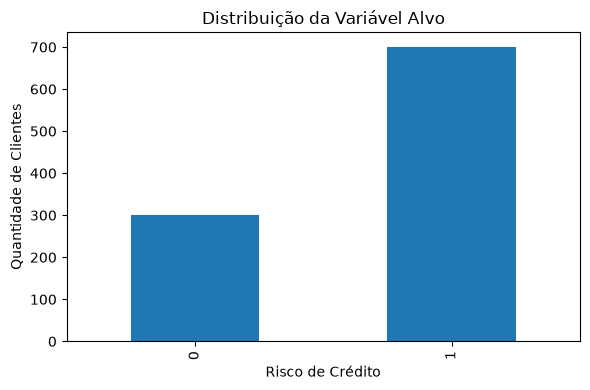

In [7]:
ax = (
    df["credit_risk"]
    .value_counts()
    .sort_index()
    .plot(
        kind="bar",
        figsize=(6, 4),
    )
)

ax.set_title("Distribuição da Variável Alvo")
ax.set_xlabel("Risco de Crédito")
ax.set_ylabel("Quantidade de Clientes")

plt.tight_layout()
plt.show()

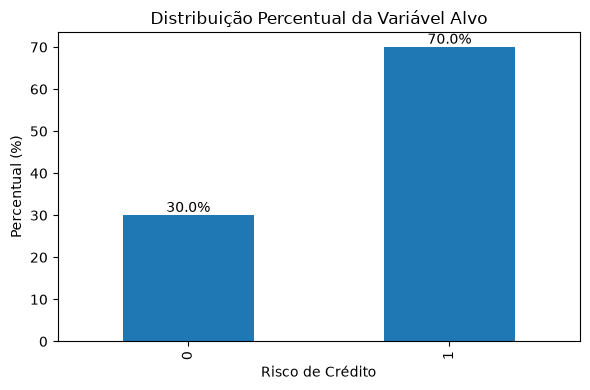

In [8]:
target_distribution = (
    df["credit_risk"].value_counts(normalize=True).sort_index().mul(100)
)

ax = target_distribution.plot(
    kind="bar",
    figsize=(6, 4),
)

ax.set_title("Distribuição Percentual da Variável Alvo")
ax.set_xlabel("Risco de Crédito")
ax.set_ylabel("Percentual (%)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

## Classificação das Variáveis

Neste conjunto de dados, as variáveis foram divididas em:

- **Variáveis numéricas:** representam valores quantitativos.
- **Variáveis categóricas:** representam categorias ou classes.
- **Variável alvo:** utilizada para treinamento dos modelos de classificação.


In [9]:
target = "credit_risk"

numeric_features = [
    "duration",
    "amount",
    "installment_rate",
    "residence_duration",
    "age",
    "existing_credits",
    "people_liable",
]

categorical_features = [
    column for column in df.columns if column not in numeric_features + [target]
]

print(f"Variáveis numéricas ({len(numeric_features)}):")
print(numeric_features)

print()

print(f"Variáveis categóricas ({len(categorical_features)}):")
print(categorical_features)

Variáveis numéricas (7):
['duration', 'amount', 'installment_rate', 'residence_duration', 'age', 'existing_credits', 'people_liable']

Variáveis categóricas (15):
['checking_account', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_duration', 'personal_status_sex', 'guarantors', 'property', 'other_installment_plans', 'housing', 'job', 'telef', 'foreign_worker']


## Análise Univariada das Variáveis Numéricas

In [11]:
numeric_features = [
    "duration_months",
    "credit_amount",
    "installment_rate",
    "residence_duration",
    "age",
    "existing_credits",
    "people_liable",
]

numeric_features

['duration_months',
 'credit_amount',
 'installment_rate',
 'residence_duration',
 'age',
 'existing_credits',
 'people_liable']

In [12]:
numeric_summary = df[numeric_features].describe().T

numeric_summary["median"] = df[numeric_features].median()
numeric_summary["skewness"] = df[numeric_features].skew()
numeric_summary["kurtosis"] = df[numeric_features].kurt()

numeric_summary = numeric_summary[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skewness",
        "kurtosis",
    ]
].round(2)

numeric_summary

,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
duration_months,1000.0,20.90,18.0,12.06,4.0,12.0,18.0,24.00,72.0,1.09,0.92
credit_amount,1000.0,3271.25,2319.5,2822.75,250.0,1365.5,2319.5,3972.25,18424.0,1.95,4.29
installment_rate,1000.0,2.97,3.0,1.12,1.0,2.0,3.0,4.00,4.0,-0.53,-1.21
residence_duration,1000.0,2.84,3.0,1.10,1.0,2.0,3.0,4.00,4.0,-0.27,-1.38
age,1000.0,35.54,33.0,11.35,19.0,27.0,33.0,42.00,75.0,1.02,0.62
existing_credits,1000.0,1.41,1.0,0.58,1.0,1.0,1.0,2.00,4.0,1.27,1.60
people_liable,1000.0,1.84,2.0,0.36,1.0,2.0,2.0,2.00,2.0,-1.91,1.65
